# Teste de treinamento de modelo para predição de Slump utilizando XGBOOST

### Importação de módulos

In [27]:
%%capture
!pip install xgboost optuna

In [28]:
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split, KFold
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
from google.colab import drive
import seaborn as sns
import pandas as pd
import numpy as np
import os, optuna

### Montagem do drive

In [29]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
dirpath = '/content/drive/MyDrive/supervised-learning-studies/projeto/slump'
filename = 'df_slump_XGBoost.pkl'
file_path = os.path.join(dirpath, filename)
os.listdir(dirpath)
df = pd.read_pickle(file_path)
df['target'] = df['Slump_mm'].copy()
df.drop(inplace=True, columns=['Slump_mm'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Agua_kg_m3            106 non-null    float64 
 1   Metodo_Emp_Cod        106 non-null    int64   
 2   Classe_Cim_OpA        106 non-null    int64   
 3   vol_ar_aprisionado    106 non-null    float64 
 4   agua_equivalente_vol  106 non-null    float64 
 5   lubrificacao_efetiva  106 non-null    float64 
 6   bins                  106 non-null    category
 7   target                106 non-null    int64   
dtypes: category(1), float64(4), int64(3)
memory usage: 6.1 KB


In [31]:
def split_target(df, target):
    df.drop(columns=['bins'], inplace=True, errors='ignore')
    y = df[target].copy()
    df.drop(columns=[target], inplace=True)
    return df, y

In [32]:
# 1. Separa 95% para treino e 5% para a teste (mantendo a proporção da coluna 'bins')
df_temp, df_test= train_test_split(
    df,
    test_size=0.05, 
    random_state=42, 
    stratify=df['bins']
)

# 2. Dos 95% restantes, divide em treino e validação, mantendo a proporção da coluna 'bins'
# Isso resulta em 70% do total para treino e 30% para validação
df_train, df_val = train_test_split(
    df_temp, 
    test_size=0.3,
    random_state=42, 
    stratify=df_temp['bins']
)

df_train.to_pickle(os.path.join(dirpath, 'df_train.pkl'))
df_test.to_pickle(os.path.join(dirpath, 'df_test.pkl'))
df_val.to_pickle(os.path.join(dirpath, 'df_val.pkl'))

X_train, y_train = split_target(df_train, 'target')
X_test, y_test = split_target(df_test, 'target')
X_val, y_val = split_target(df_val, 'target')

In [33]:
print(sum([df_train.isna().sum(), df_test.isna().sum(), df_val.isna().sum()]))

Agua_kg_m3              0
Metodo_Emp_Cod          0
Classe_Cim_OpA          0
vol_ar_aprisionado      0
agua_equivalente_vol    0
lubrificacao_efetiva    0
dtype: int64


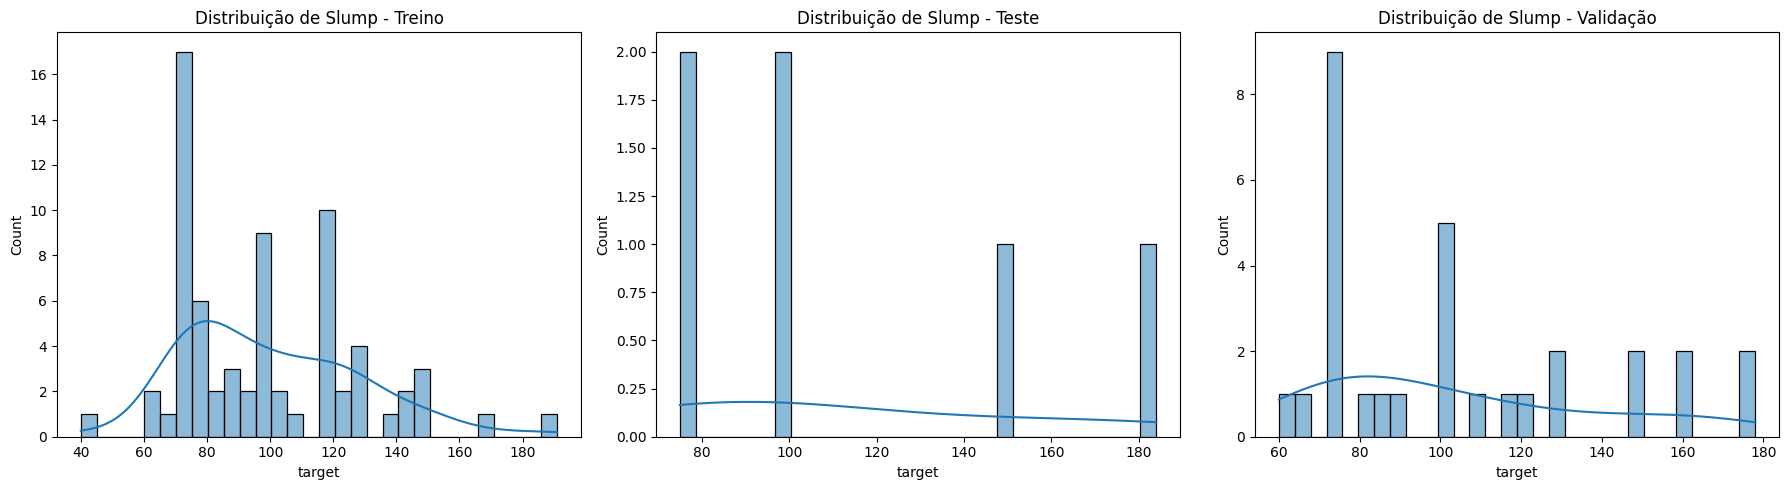

In [34]:
figure, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(y_train, bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribuição de Slump - Treino')
sns.histplot(y_test, bins=30, kde=True, ax=axes[1])
axes[1].set_title('Distribuição de Slump - Teste')
sns.histplot(y_val, bins=30, kde=True, ax=axes[2])
axes[2].set_title('Distribuição de Slump - Validação')
plt.tight_layout()
plt.show()

### Validação dos dados de teste, treino e validação

In [35]:
print(f"X_train shape: {X_train.shape}\nX_test shape: {X_test.shape}\nX_val shape: {X_val.shape}\n")
assert X_train.columns.equals(X_test.columns) and X_train.columns.equals(X_val.columns), "As colunas dos DataFrames de treino, teste e validação não são iguais."
print("X_train" + "\n" + "\n".join(f"{c}: {X_train[c].dtype} (NAs: {X_train[c].isna().sum()})" for c in X_train.columns) + "\n")
print("X_test" + "\n" + "\n".join(f"{c}: {X_test[c].dtype} (NAs: {X_test[c].isna().sum()})" for c in X_test.columns) + "\n")
print("X_val" + "\n" + "\n".join(f"{c}: {X_val[c].dtype} (NAs: {X_val[c].isna().sum()})" for c in X_val.columns) + "\n")

X_train shape: (70, 6)
X_test shape: (6, 6)
X_val shape: (30, 6)

X_train
Agua_kg_m3: float64 (NAs: 0)
Metodo_Emp_Cod: int64 (NAs: 0)
Classe_Cim_OpA: int64 (NAs: 0)
vol_ar_aprisionado: float64 (NAs: 0)
agua_equivalente_vol: float64 (NAs: 0)
lubrificacao_efetiva: float64 (NAs: 0)

X_test
Agua_kg_m3: float64 (NAs: 0)
Metodo_Emp_Cod: int64 (NAs: 0)
Classe_Cim_OpA: int64 (NAs: 0)
vol_ar_aprisionado: float64 (NAs: 0)
agua_equivalente_vol: float64 (NAs: 0)
lubrificacao_efetiva: float64 (NAs: 0)

X_val
Agua_kg_m3: float64 (NAs: 0)
Metodo_Emp_Cod: int64 (NAs: 0)
Classe_Cim_OpA: int64 (NAs: 0)
vol_ar_aprisionado: float64 (NAs: 0)
agua_equivalente_vol: float64 (NAs: 0)
lubrificacao_efetiva: float64 (NAs: 0)



### Validação dos targets

In [36]:
print(f"y_train shape: {y_train.shape}\ny_test shape: {y_test.shape}\ny_val shape: {y_val.shape}\n")
print("y_train" + "\n" + f"{y_train.name}: {y_train.dtype} (NAs: {y_train.isna().sum()})" + "\n")
print("y_test" + "\n" + f"{y_test.name}: {y_test.dtype} (NAs: {y_test.isna().sum()})" + "\n")
print("y_val" + "\n" + f"{y_val.name}: {y_val.dtype} (NAs: {y_val.isna().sum()})" + "\n")

y_train shape: (70,)
y_test shape: (6,)
y_val shape: (30,)

y_train
target: int64 (NAs: 0)

y_test
target: int64 (NAs: 0)

y_val
target: int64 (NAs: 0)



In [37]:
hyper_params = {
    "booster": "dart", 
    "sample_type": "uniform",
    "normalize_type": "tree", 
    "rate_drop": 0.01,
    "n_estimators": 400,
    "learning_rate": 0.03,
    "max_depth": 2,
    "min_child_weight": 2,
    "subsample": 0.15,
    "colsample_bytree": 0.4,
    "reg_lambda": 3,
    "reg_alpha": 0.4,
    "random_state": 42,
    "eval_metric": "rmse"
}

In [38]:
model = XGBRegressor(**hyper_params)

In [39]:
%%time
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

# Recupera resultados de avaliação por iteração
evals_result = model.evals_result()

CPU times: user 11.2 s, sys: 376 ms, total: 11.6 s
Wall time: 8.05 s


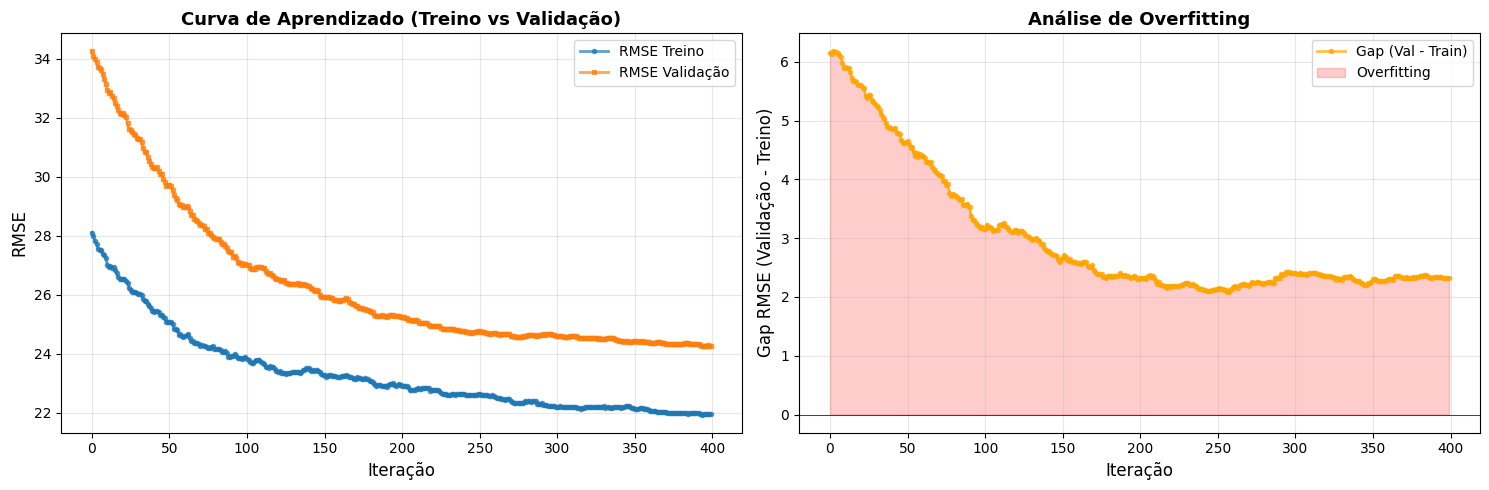

In [40]:
# Plotar curvas de aprendizado (treino vs validação)
train_rmse = evals_result.get('validation_0', {}).get('rmse', [])
val_rmse = evals_result.get('validation_1', {}).get('rmse', [])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Curva de aprendizado completa
ax1 = axes[0]
iterations = range(len(train_rmse))
ax1.plot(iterations, train_rmse, label='RMSE Treino', marker='o', markersize=3, alpha=0.7, linewidth=2)
ax1.plot(iterations, val_rmse, label='RMSE Validação', marker='s', markersize=3, alpha=0.7, linewidth=2)
ax1.set_xlabel('Iteração', fontsize=12)
ax1.set_ylabel('RMSE', fontsize=12)
ax1.set_title('Curva de Aprendizado (Treino vs Validação)', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Gráfico 2: Gap de overfitting (Validação - Treino)
ax2 = axes[1]
gap = np.array(val_rmse) - np.array(train_rmse)
ax2.plot(iterations, gap, label='Gap (Val - Train)', marker='o', markersize=3, alpha=0.7, linewidth=2, color='orange')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.fill_between(iterations, 0, gap, where=(gap > 0), alpha=0.2, color='red', label='Overfitting')
ax2.set_xlabel('Iteração', fontsize=12)
ax2.set_ylabel('Gap RMSE (Validação - Treino)', fontsize=12)
ax2.set_title('Análise de Overfitting', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [41]:
# Estatísticas finais
train_final = train_rmse[-1]
val_final = val_rmse[-1]
overfitting_gap = val_final - train_final

print("\n" + "="*60)
print("📊 ANÁLISE DE OVERFITTING E PERFORMANCE")
print("="*60)
print(f"✅ RMSE Treino (final):      {train_final:.6f}")
print(f"⚠️  RMSE Validação (final):   {val_final:.6f}")
print(f"📈 Gap (Val - Train):        {overfitting_gap:.6f}")
print("="*60)


📊 ANÁLISE DE OVERFITTING E PERFORMANCE
✅ RMSE Treino (final):      21.946189
⚠️  RMSE Validação (final):   24.270930
📈 Gap (Val - Train):        2.324741


In [42]:
# Fazer predições no conjunto de teste
y_pred = model.predict(X_test)
debug_df = X_test.copy()

debug_df["pred"] = y_pred
debug_df["ground_truth"] = y_test
debug_df["residual"] = debug_df["ground_truth"] - debug_df["pred"]

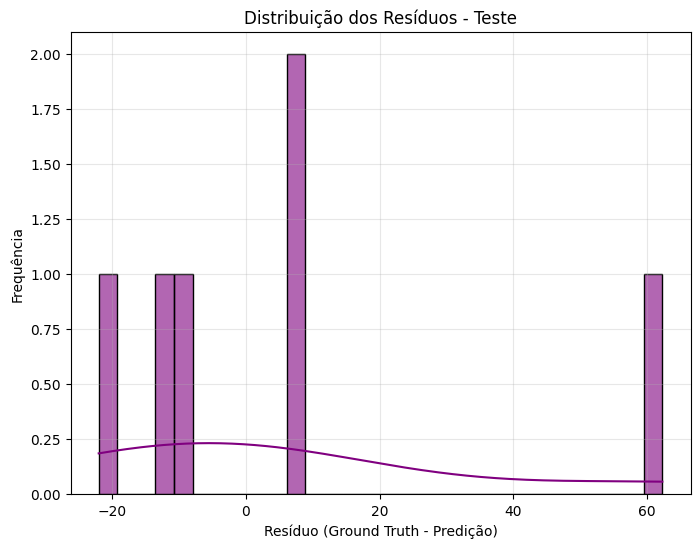

In [43]:
plt.figure(figsize=(8, 6))
sns.histplot(debug_df["residual"], bins=30, kde=True, color='purple', alpha=0.6)
plt.title("Distribuição dos Resíduos - Teste")
plt.xlabel("Resíduo (Ground Truth - Predição)")
plt.ylabel("Frequência")
plt.grid(True, alpha=0.3)
plt.show()

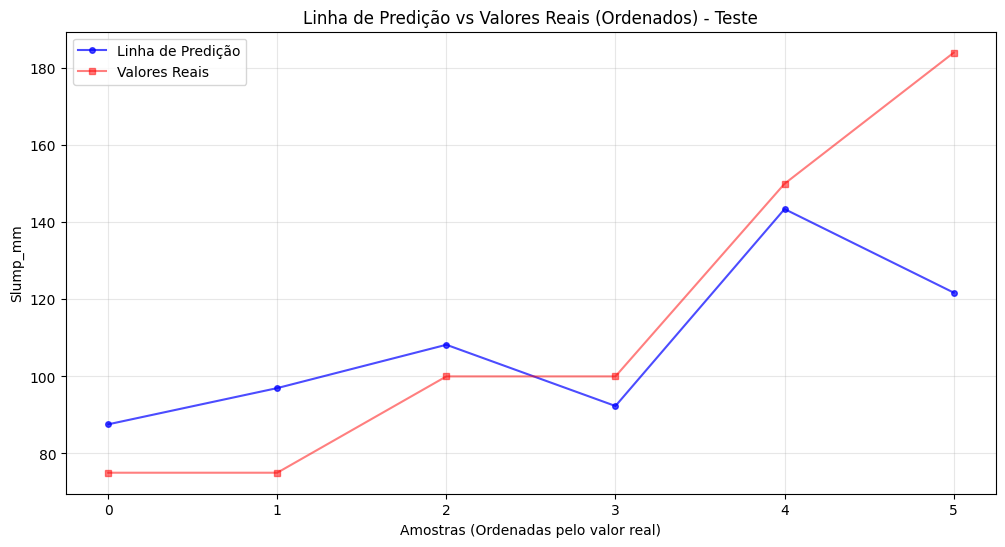

In [44]:
# Ordenando pelo valor real para a linha de predição não virar um "zigue-zague"
debug_df = debug_df.sort_values(by="ground_truth").reset_index(drop=True)
indices = range(len(debug_df))

plt.figure(figsize=(12, 6))

# 1. Linha das Predições (conectando os pontos preditos)
plt.plot(indices, debug_df["pred"], color='blue', label="Linha de Predição", 
         alpha=0.7, linewidth=1.5, marker='o', markersize=4)

# 2. Pontos dos Valores Reais (Ground Truth)
plt.plot(indices, debug_df["ground_truth"], color='red', label="Valores Reais", 
            alpha=0.5, linewidth=1.5, marker='s', markersize=4)

plt.title("Linha de Predição vs Valores Reais (Ordenados) - Teste")
plt.xlabel("Amostras (Ordenadas pelo valor real)")
plt.ylabel("Slump_mm")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [45]:
r2 = r2_score(debug_df["ground_truth"], debug_df["pred"])
rmse = root_mean_squared_error(debug_df["ground_truth"], debug_df["pred"])
mae = mean_absolute_error(debug_df["ground_truth"], debug_df["pred"])
mape = mean_absolute_percentage_error(debug_df["ground_truth"], debug_df["pred"])

print(f"root_mean_squared_error: {rmse:.4f}")
print(f"mean_absolute_error: {mae:.4f}")
print(f"mean_absolute_percentage_error: {mape:.4f}")
print(f"R² Score: {(r2*100):.4f}")

root_mean_squared_error: 27.9450
mean_absolute_error: 19.8742
mean_absolute_percentage_error: 0.1669
R² Score: 51.3443


In [46]:
y_val_pred = model.predict(X_val)
validation_df = X_val.copy()

validation_df["pred"] = y_val_pred
validation_df["ground_truth"] = y_val
validation_df["residual"] = validation_df["ground_truth"] - validation_df["pred"]

Text(0.5, 1.0, 'Distribuição dos Resíduos - Validação')

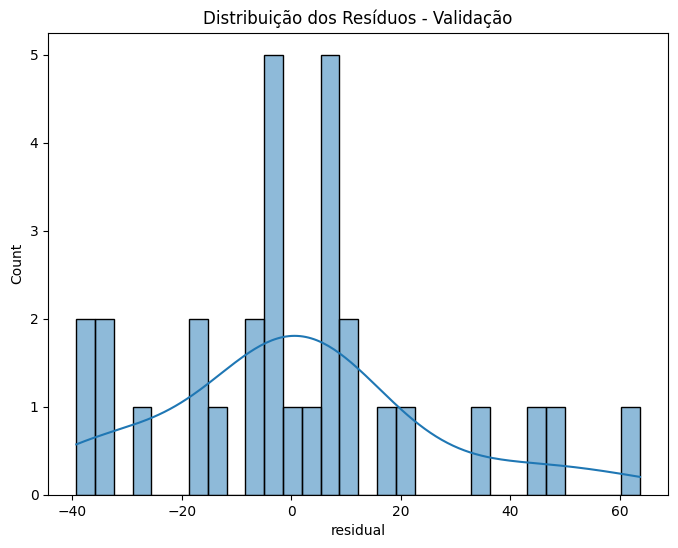

In [47]:
plt.figure(figsize=(8, 6))
sns.histplot(validation_df["residual"], bins=30, kde=True)
plt.title("Distribuição dos Resíduos - Validação")

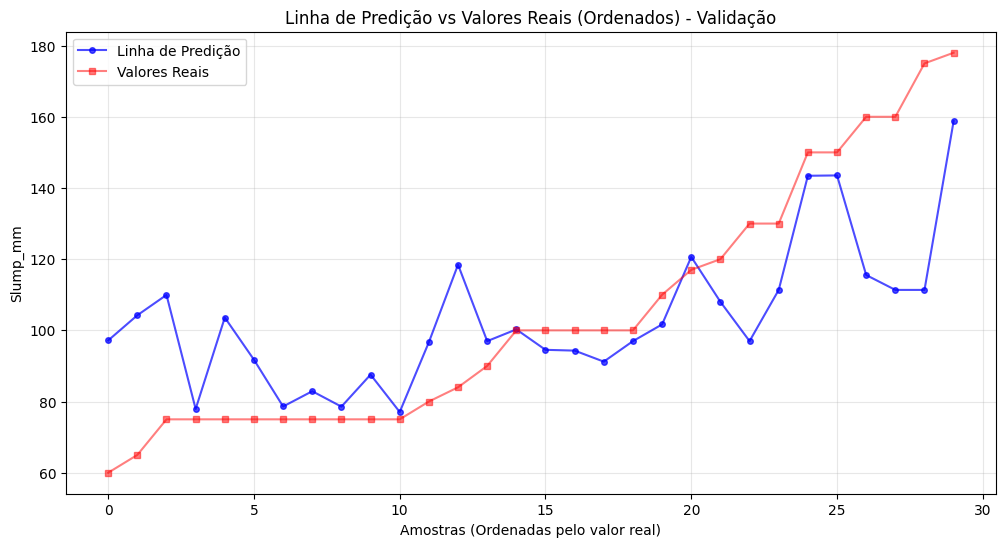

In [48]:
# Ordenando pelo valor real para a linha de predição não virar um "zigue-zague"
validation_df = validation_df.sort_values(by="ground_truth").reset_index(drop=True)
indices = range(len(validation_df))

plt.figure(figsize=(12, 6))

# 1. Linha das Predições (conectando os pontos preditos)
plt.plot(indices, validation_df["pred"], color='blue', label="Linha de Predição", 
         alpha=0.7, linewidth=1.5, marker='o', markersize=4)

# 2. Pontos dos Valores Reais (Ground Truth)
plt.plot(indices, validation_df["ground_truth"], color='red', label="Valores Reais", 
            alpha=0.5, linewidth=1.5, marker='s', markersize=4)

plt.title("Linha de Predição vs Valores Reais (Ordenados) - Validação")
plt.xlabel("Amostras (Ordenadas pelo valor real)")
plt.ylabel("Slump_mm")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [49]:
r2 = r2_score(validation_df["ground_truth"], validation_df["pred"])
rmse = root_mean_squared_error(validation_df["ground_truth"], validation_df["pred"])
mae = mean_absolute_error(validation_df["ground_truth"], validation_df["pred"])
mape = mean_absolute_percentage_error(validation_df["ground_truth"], validation_df["pred"])

print(f"root_mean_squared_error: {rmse:.4f}")
print(f"mean_absolute_error: {mae:.4f}")
print(f"mean_absolute_percentage_error: {mape:.4f}")
print(f"R² Score: {(r2*100):.4f}")

root_mean_squared_error: 24.2709
mean_absolute_error: 17.8418
mean_absolute_percentage_error: 0.1800
R² Score: 49.6593


In [50]:
model_path = os.path.join(dirpath, "melhor_modelo_slump.json")
model.save_model(model_path)
print(f"✅ Modelo salvo em: {model_path}")
print(f"\n📋 Informações do Modelo:")
print(f"  • Número de features: {model.n_features_in_}")
print(f"  • Número de boosting rounds: {model.get_num_boosting_rounds()}")

✅ Modelo salvo em: /content/drive/MyDrive/supervised-learning-studies/projeto/slump/melhor_modelo_slump.json

📋 Informações do Modelo:
  • Número de features: 6
  • Número de boosting rounds: 400


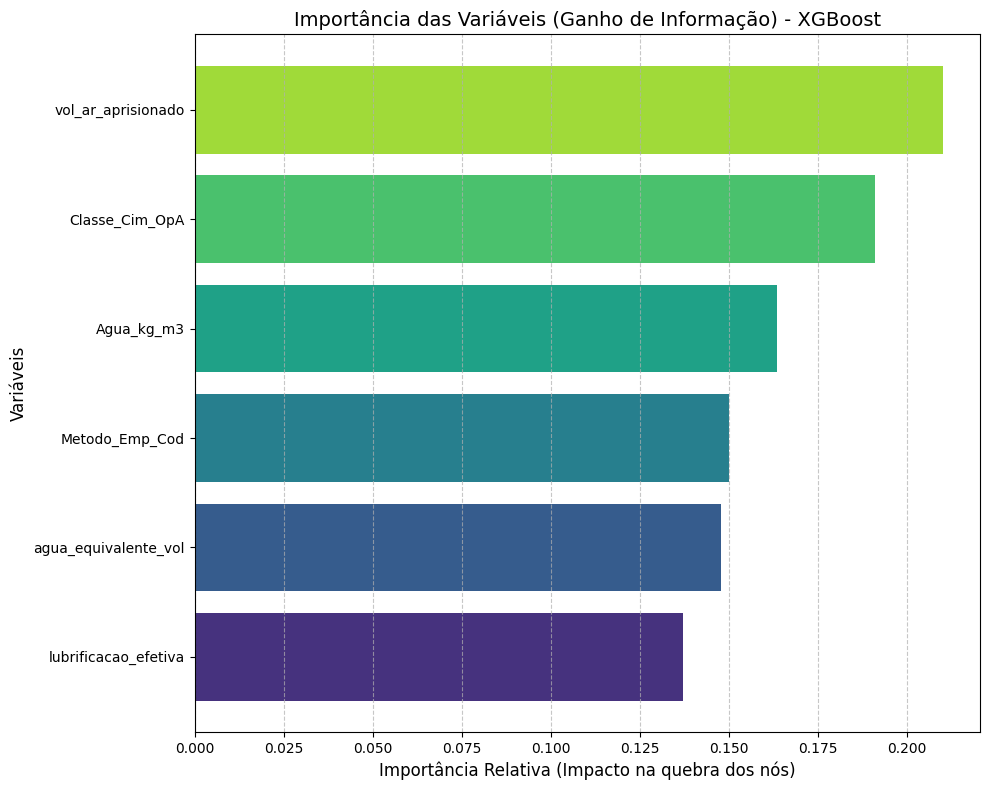

In [51]:
# 1. Extraindo as importâncias direto do modelo XGBoost treinado
# (Assumindo que o seu modelo se chame 'model_xgb')
importancias_xgb = model.feature_importances_

# 2. Criando o DataFrame para organizar os dados
df_importancia_xgb = pd.DataFrame({
    'Feature': X_train.columns,
    'Importancia': importancias_xgb
})

# Ordenando da maior para a menor importância
df_importancia_xgb = df_importancia_xgb.sort_values(by='Importancia', ascending=True)

# 3. Plotando o Gráfico
plt.figure(figsize=(10, 8))

# Criando uma paleta de cores (usando o 'viridis' para diferenciar do gráfico anterior)
cores = sns.color_palette('viridis', n_colors=len(df_importancia_xgb))

# Plotando as barras horizontais
plt.barh(
    y=df_importancia_xgb['Feature'], 
    width=df_importancia_xgb['Importancia'],
    color=cores,
    edgecolor='none'
)

plt.title('Importância das Variáveis (Ganho de Informação) - XGBoost', fontsize=14)
plt.xlabel('Importância Relativa (Impacto na quebra dos nós)', fontsize=12)
plt.ylabel('Variáveis', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [52]:
df_importancia_xgb.sort_values(by='Importancia', ascending=False)

,Feature,Importancia
3,vol_ar_aprisionado,0.210118
2,Classe_Cim_OpA,0.191103
0,Agua_kg_m3,0.163513
1,Metodo_Emp_Cod,0.150116
4,agua_equivalente_vol,0.147893
5,lubrificacao_efetiva,0.137257
